In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import seaborn as sns
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

import wandb
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from itertools import combinations

from collections import defaultdict

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 17.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 16.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.6/289.6 kB 27.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 2.9 MB/s eta 0:00:00


In [ ]:
encoder_path = '/content/drive/MyDrive/grad_school/thesis/mass_spec/models/icmla_encoder_small_dataset.pth'
generator_path = '/content/drive/MyDrive/grad_school/thesis/mass_spec/models/icmla_generator_small_dataset.pth'
noisy_encoder_path = '/content/drive/MyDrive/grad_school/thesis/mass_spec/models/icmla_noisy_encoder_small_dataset.pth'
noisy_generator_path = '/content/drive/MyDrive/grad_school/thesis/mass_spec/models/icmla_noisy_generator_small_dataset.pth'

# Set up WandB:
---

In [ ]:
config = {
    'wandb_entity': 'catemerfeld',
    'wandb_project': 'mass_spec',
    'gpu':True,
    'threads':1,
}

os.environ['WANDB_NOTEBOOK_NAME'] = 'spider_for_icmla_paper_.ipynb'

In [ ]:
def run_with_wandb(config, **kwargs):
    config.update(kwargs)

    wandb.init(entity=config['wandb_entity'],
               project=config['wandb_project'],
               config=config)

    # Set the number of threads
    torch.set_num_threads(config['threads'])

    # Find out is there is a GPU available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if not config['gpu']:
        device = torch.device('cpu')
    print(f'Using device: {device}')

# Loading the Data:
---

In [ ]:
# # 50 chemical dataset with condition info and chemical encodings
# spectra_df = pd.read_csv('/content/drive/MyDrive/grad_school/thesis/mass_spec/data/scaled_spectra_with_instrument_type.csv')
# embeddings = pd.read_csv('/content/drive/MyDrive/grad_school/thesis/mass_spec/data/MoNA_embeddings_multiple_instrument_types.csv')

# 39 chemical dataset - no condition info/name encodings
spectra_df = pd.read_csv('/content/drive/MyDrive/grad_school/thesis/mass_spec/data/scaled_spectra.csv')
embeddings = pd.read_csv('/content/drive/MyDrive/grad_school/thesis/mass_spec/data/MoNA_embeddings_big_df.csv')

# Set Up Dataset:
---

In [ ]:
# Only needed for 39 chemical dataset

# One hot encode chemical names
encoder = OneHotEncoder()
chem_names = [chem.split('.')[0] for chem in spectra_df.columns]
chemical_encodings = encoder.fit_transform(np.array(chem_names).reshape(-1, 1))
chemical_encodings = torch.tensor(chemical_encodings.toarray())

data = torch.tensor(spectra_df.T.values, dtype=torch.float)

# set max idx for random fill ins
random_range = 797

In [ ]:
# # chemical name encodings are currently stored between indices 915 and 965 in each data point
# chemical_encodings = torch.tensor(spectra_df[:][915:965].T.values, dtype=torch.float)
# # removing name embeddings and condition information, truncating to 650 --------------NOT CURRENTLY TRUNCATING
# data = torch.tensor(spectra_df[:][:915].T.values, dtype=torch.float)

# # set max idx for random fill ins
# random_range = 797

In [ ]:
# truth based on length of spectra - if truncating to 650, change truth to 'spider_650'
# truth = 'spider_915'
truth = 'spider_797'
x_train, x_test, train_chem_encodings, test_chem_encodings = train_test_split(data, chemical_encodings, test_size=.2, random_state = 42)

In [ ]:
sorted_chem_names = sorted(list(set(chem.split('.')[0] for chem in spectra_df.columns)))

# making list of each data point's Chemception embedding (based on chemical name)
train_chems = [sorted_chem_names[list(encoding).index(1)] for encoding in train_chem_encodings]
train_embeddings = torch.Tensor([embeddings[chem_name] for chem_name in train_chems])

test_chems = [sorted_chem_names[list(encoding).index(1)] for encoding in test_chem_encodings]
test_embeddings = torch.Tensor([embeddings[chem_name] for chem_name in test_chems])

batch_size = 100
train_dataset = DataLoader(TensorDataset(x_train, train_chem_encodings, train_embeddings), batch_size=batch_size, shuffle=True)
test_dataset = DataLoader(TensorDataset(x_test, test_chem_encodings, test_embeddings), batch_size=batch_size, shuffle=True)

In [ ]:
def generate_noisy_dataset(spectra, chem_encodings, embeddings, batch_size, random_range, num_noisy_per_real = 5, fill_num=100):
  noisy_spectra = []
  clean_spectra = []
  noisy_spectra_chem_encodings = []
  noisy_spectra_embeddings = []

  for spec, chem_encoding, embedding in zip(spectra, chem_encodings, embeddings):
    for _ in range(num_noisy_per_real):
      # fill in fill_num random numbers of each spectrum with 0s
      noisy_spec = spec.clone()
      random_numbers = random.sample(range(random_range), fill_num)
      for num in random_numbers:
        noisy_spec[num] = 0
      noisy_spectra.append(torch.Tensor(noisy_spec))
      clean_spectra.append(torch.Tensor(spec))
      noisy_spectra_chem_encodings.append(chem_encoding)
      noisy_spectra_embeddings.append(embedding)

  noisy_spectra = torch.stack(noisy_spectra)
  clean_spectra = torch.stack(clean_spectra)
  noisy_spectra_chem_encodings = torch.stack(noisy_spectra_chem_encodings)
  noisy_spectra_embeddings = torch.stack(noisy_spectra_embeddings)


  noisy_dataset = DataLoader(TensorDataset(noisy_spectra, clean_spectra, noisy_spectra_chem_encodings, noisy_spectra_embeddings), batch_size=batch_size, shuffle=True)

  return noisy_dataset

# Loss Function Definitions:
---

Using cosine similarity implementation from scipy.spatial.distance.cosine:
<br>
<br>
\begin{align}
\frac{\sum_{i}{w_i u_i v_i}}{\sqrt{\sum_{i}w_i u_i^2}\sqrt{\sum_{i}w_i v_i^2}}
\end{align}

Where $w$ are the weights and $u$ and $v$ are the two vectors being compared.

This is the implementation I used below.

$MSE + λ Weighted Cosine Loss$

$\lambda = 10$

In [ ]:
class WeightedCosineSimilarityLoss(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, output, target):
    # it is common to use m/z ratio as weights since fragments with higher m/z ratios are more important.
    mz = torch.arange(1, len(target)+1)

    numerator = torch.sum(mz*output*target)
    output_denom = torch.sqrt(torch.sum(mz*output**2))
    target_denom = torch.sqrt(torch.sum(mz*target**2))

    weighted_cosine_similarity = numerator/(output_denom*target_denom)

    # weighted cosine is a similarity metric between 0 and 1 (higher numbers mean more similarity).
    # to use it as a loss function I'm subtracting the similarity from 1
    weighted_cosine_loss = torch.tensor(1-weighted_cosine_similarity, requires_grad=True)
    return(weighted_cosine_loss)

# Helper Functions:
---

In [ ]:
def plot_emb_pca(all_embeddings, all_chemical_names, output_embeddings, output_labels):
    """
    Run pca on embeddings from denoiser output. Plot results against PCA of Chemception embeddings.

    Args:
    - all_embeddings (pd.DataFrame): Column headers are chemical names. Each column represents one chemical's Chemception embedding.
    - all_chemical_names (list): Sorted list of all chemical names in the training data.
    - output_embeddings (list): Encoder output embeddings.
    - output_labels (list): Chemical names for each embedding in the encoder's output.
    """

    pca = PCA(n_components=2)
    pca.fit(all_embeddings.T)

    # Extract true embeddings for all chemicals and transform them using the fitted PCA
    true_embeddings = [all_embeddings[chem] for chem in all_chemical_names]
    true_transformed = pca.transform(true_embeddings)

    # Transform the encoder output embeddings using the same PCA
    output_transformed = pca.transform(output_embeddings)

    # Create a color map where each chemical name is assigned a unique integer
    color_map = {chem: idx for idx, chem in enumerate(all_chemical_names)}

    # Map chemical names to their respective colors for the true embeddings
    true_colors = [color_map[chem] for chem in all_chemical_names]
    # Map chemical names to their respective colors for the output embeddings
    output_colors = [color_map[chem] for chem in output_labels]

    # Extract the x and y coordinates from the transformed true embeddings
    true_x = [pair[0] for pair in true_transformed]
    true_y = [pair[1] for pair in true_transformed]
    # Extract the x and y coordinates from the transformed true embeddings
    scatter = plt.scatter(true_x, true_y, c=true_colors, cmap='tab20')

    # Extract the x and y coordinates from the transformed output embeddings
    output_x = [pair[0] for pair in output_transformed]
    output_y = [pair[1] for pair in output_transformed]
    # Create a scatter plot for the output embeddings
    plt.scatter(output_x, output_y, marker='x', c=output_colors, cmap='tab20')

    # Add a legend to the plot
    plt.legend(handles=scatter.legend_elements()[0],
                labels=all_chemical_names,
                loc='upper right',
                prop={'size':7})


    plt.title('Chemception Embeddings vs. Denoiser Output')
    plt.xticks([])
    plt.yticks([])

    plt.show()

In [ ]:
def get_weighted_cosine_similarity(output, target):
  # it is common to use m/z ratio as weights since fragments with higher m/z ratios are more important.
  mz = torch.arange(1, len(target)+1)

  numerator = torch.sum(mz*output*target)
  output_denom = torch.sqrt(torch.sum(mz*output**2))
  target_denom = torch.sqrt(torch.sum(mz*target**2))

  weighted_cosine_similarity = numerator/(output_denom*target_denom)
  return(weighted_cosine_similarity)

In [ ]:
def plot_results(real_spectra, fake_spectra, labels, idx=[0,5], window=300, cutoff = 0.5):
  """
  Plot and compare real and synthetic spectra within a specified index range.

  Takes in real, noisy, and synthetic spectra and plots them for comparison.
  Computes and prints the weighted cosine similarity between the real spectrum and
  both the noisy and synthetic spectra.

  Args:
      real_spectra (list of list of float): List of real spectra, where each spectrum is a list of intensity values.
      fake_spectra (list of list of float): List of synthetic spectra generated by decoder.
      labels (list of str): List of chemical name labels corresponding to each spectrum.
      idx (list of int, optional): Range of indices to plot. Default is [0, 10].
      window (int, optional): Highest m/z to plot for each spectrum. Default is 300.
      cutoff (float, optional): Intensity cutoff threshold to filter out low-intensity noise. Default is 0.5.
  """
  for i, (real_spec, fake_spec) in enumerate(zip(real_spectra, fake_spectra)):
    # only plot spectra within the specified index range
    if i > idx[1]:
      break
    if idx[0] <= i < idx[1]:
      # Define the x-axis range
      numbers = range(0, window)

      # Scale the real spectrum so highest peak is 100
      input_frequencies = real_spec.copy()
      input_max = max(input_frequencies)
      scaled_input = [num/input_max * 100 for num in input_frequencies]

      # Scale the synthetic spectrum so highest peak is 100
      out_clone = fake_spec.copy()
      output_max = max(out_clone)
      scaled_out = [num/output_max * 100 for num in out_clone]
      out_frequencies = [0 if num < cutoff else num for num in scaled_out]

      weighted_cosine_similarity = get_weighted_cosine_similarity(out_clone, input_frequencies)

      # Create a plot with 2 subplots for real and synthetic spectra
      _, ax = plt.subplots(nrows=1, ncols=2, sharex=True, sharey=True, figsize=(20, 10))

      ax[0].bar(numbers, scaled_input[:window])
      ax[0].set_title(f'True {labels[i]} Spectrum.', fontsize=18)
      ax[0].set_xlabel('Mass to Charge Ratio', fontsize=16)
      ax[0].set_ylabel('Intensity', fontsize=16)

      ax[1].bar(numbers, out_frequencies[:window])
      ax[1].set_title(f'Synthetic {labels[i]} Spectrum.', fontsize=18)
      print('Weighted cosine similarity between true spectrum and output spectrum is: ', round(float(weighted_cosine_similarity), 2))
      ax[1].set_xlabel('Mass to Charge Ratio', fontsize=16)
      ax[1].set_ylabel('Intensity', fontsize=16)

      plt.tight_layout()
      plt.show()

In [ ]:
# chem = 'Undecane'
# chem_columns = list(spectra_df.filter(like=chem).columns)
# chem_subset = spectra_df[chem_columns][:915]
# for i, col in enumerate(chem_subset.columns):
#   col_2 = chem + '.' + str(i+1)
#   sim = get_weighted_cosine_similarity(torch.tensor(spectra_df[col]), torch.tensor(spectra_df[col_2]))
#   print(round(sim.item(), 3))

In [ ]:
# sorted_chem_names = sorted(list(set(chem.split('.')[0] for chem in spectra_df.columns)))

# chem_similarities = []
# plotting_chems_1 = []
# plotting_chems_2 = []
# labels = []
# # Calculate pairwise similarity between all spectra for each chemical
# for chem in sorted_chem_names:
#     chem_columns = list(spectra_df.filter(like=chem).columns)
#     chem_subset = spectra_df[chem_columns][:797].T.values
#     # print(chem_subset.shape)

#     for i, j in combinations(range(len(chem_subset)), 2):
#         # print(i, j)
#         similarity = get_weighted_cosine_similarity(chem_subset[i], chem_subset[j])
#         # print(len(chem_subset[i]))
#         # print(round(similarity.item(),3))
#         plotting_chems_1.append(chem_subset[i])
#         plotting_chems_2.append(chem_subset[j])
#         labels.append([i,j])
#         chem_similarities.append(similarity.item())
#     # break

In [ ]:
# plt.hist(chem_similarities, bins=20, alpha=0.5, color='blue')

# plt.xlabel('Similarity')
# plt.ylabel('Frequency')
# plt.title('Frequency of Similarity Values')

# plt.show()

# Model Definitions:
---

In [ ]:
class Encoder(nn.Module):
  def __init__(self):
    super().__init__()

    # self.encoder = nn.Sequential(
      # nn.Linear(915,878),
      # nn.LeakyReLU(inplace=True),
      # nn.Linear(878,841),
      # nn.LeakyReLU(inplace=True),
      # nn.Linear(841,804),
      # nn.LeakyReLU(inplace=True),
      # nn.Linear(804,767),
      # nn.LeakyReLU(inplace=True),
      # nn.Linear(767, 730),
      # nn.LeakyReLU(inplace=True),
      # nn.Linear(730, 693),
      # nn.LeakyReLU(inplace=True),
      # nn.Linear(693, 656),
      # nn.LeakyReLU(inplace=True),
      # nn.Linear(656, 619),
      # # nn.Linear(650,619),
      # nn.LeakyReLU(inplace=True),
      # nn.Linear(619, 582),
      # nn.LeakyReLU(inplace=True),
      # nn.Linear(582, 545),
      # nn.LeakyReLU(inplace=True),
      # nn.Linear(545, 512),
    # )
    self.encoder = nn.Sequential(
      nn.Linear(797,765),
      nn.LeakyReLU(inplace=True),
      nn.Linear(765,733),
      nn.LeakyReLU(inplace=True),
      nn.Linear(733,701),
      nn.LeakyReLU(inplace=True),
      nn.Linear(701,669),
      nn.LeakyReLU(inplace=True),
      nn.Linear(669, 637),
      nn.LeakyReLU(inplace=True),
      nn.Linear(637, 605),
      nn.LeakyReLU(inplace=True),
      nn.Linear(605, 573),
      nn.LeakyReLU(inplace=True),
      nn.Linear(573, 541),
      nn.LeakyReLU(inplace=True),
      nn.Linear(541, 512),
    )

  def forward(self, x):
    x = self.encoder(x)
    return x

In [ ]:
class Generator(nn.Module):
  def __init__(self):
    super().__init__()

    # self.generator = nn.Sequential(
    #   # nn.Linear(512,545),
    #   # nn.LeakyReLU(inplace=True),
    #   # nn.Linear(545, 582),
    #   # nn.LeakyReLU(inplace=True),
    #   # nn.Linear(582, 619),
    #   # nn.LeakyReLU(inplace=True),
    #   # nn.Linear(619, 650),
    #   nn.Linear(512, 573),
    #   nn.LeakyReLU(inplace=True),
    #   nn.Linear(573, 611),
    #   nn.LeakyReLU(inplace=True),
    #   nn.Linear(611, 649),
    #   nn.LeakyReLU(inplace=True),
    #   nn.Linear(649, 687),
    #   nn.LeakyReLU(inplace=True),
    #   nn.Linear(687, 725),
    #   nn.LeakyReLU(inplace=True),
    #   nn.Linear(725, 763),
    #   nn.LeakyReLU(inplace=True),
    #   nn.Linear(763, 801),
    #   nn.LeakyReLU(inplace=True),
    #   nn.Linear(801, 839),
    #   nn.LeakyReLU(inplace=True),
    #   nn.Linear(839, 877),
    #   nn.LeakyReLU(inplace=True),
    #   nn.Linear(877, 915)
    # )

    self.generator = nn.Sequential(

      nn.Linear(512,541),
      nn.LeakyReLU(inplace=True),
      nn.Linear(541,573),
      nn.LeakyReLU(inplace=True),
      nn.Linear(573,605),
      nn.LeakyReLU(inplace=True),
      nn.Linear(605,637),
      nn.LeakyReLU(inplace=True),
      nn.Linear(637, 669),
      nn.LeakyReLU(inplace=True),
      nn.Linear(669, 701),
      nn.LeakyReLU(inplace=True),
      nn.Linear(701, 733),
      nn.LeakyReLU(inplace=True),
      nn.Linear(733, 765),
      nn.LeakyReLU(inplace=True),
      nn.Linear(765, 797),
    )

  def forward(self, x):
    x = self.generator(x)
    return x

# Train Encoder:
---


In [ ]:
epochs = 300
learning_rate = .0001
encoder = Encoder()

encoder_optimizer = torch.optim.AdamW(encoder.parameters(), lr = learning_rate)
encoder_criterion = nn.MSELoss()

predicted_embeddings = []
output_chem_names = []

for epoch in range(epochs):
  # accumulate epoch loss
  epoch_training_loss = 0

  for batch, name_encodings, true_embeddings in train_dataset:
    batch_predicted_embeddings = encoder(batch)

    loss = encoder_criterion(batch_predicted_embeddings, true_embeddings)
    epoch_training_loss += loss

    # back propogation
    encoder_optimizer.zero_grad()
    loss.backward()
    encoder_optimizer.step()

    # at last epoch store output embeddings and corresponding labels to output list
    if (epoch + 1) == epochs:
      chem_names = [sorted_chem_names[list(encoding).index(1)] for encoding in name_encodings]
      for emb, chem_name in zip(batch_predicted_embeddings, chem_names):
        predicted_embeddings.append(emb)
        output_chem_names.append(chem_name)

  average_loss = epoch_training_loss/len(train_dataset)

  if (epoch + 1) % 10 == 0:
    print('Epoch[{}/{}], loss: {}'.format(epoch+1, epochs, average_loss))

Epoch[10/300], loss: 0.04503164812922478
Epoch[20/300], loss: 0.0378621406853199
Epoch[30/300], loss: 0.026766085997223854
Epoch[40/300], loss: 0.018517756834626198
Epoch[50/300], loss: 0.012761118821799755
Epoch[60/300], loss: 0.00859253853559494
Epoch[70/300], loss: 0.0060103596188127995
Epoch[80/300], loss: 0.0043534473516047
Epoch[90/300], loss: 0.002961954800412059
Epoch[100/300], loss: 0.0020394551102072
Epoch[110/300], loss: 0.0014886744320392609
Epoch[120/300], loss: 0.0010527168633416295
Epoch[130/300], loss: 0.0007903152145445347
Epoch[140/300], loss: 0.0006223602104000747
Epoch[150/300], loss: 0.0004805863427463919
Epoch[160/300], loss: 0.0003818724362645298
Epoch[170/300], loss: 0.0003286524151917547
Epoch[180/300], loss: 0.00027849513571709394
Epoch[190/300], loss: 0.00023466900165658444
Epoch[200/300], loss: 0.00020759168546646833
Epoch[210/300], loss: 0.00017728186503518373
Epoch[220/300], loss: 0.00015877984696999192
Epoch[230/300], loss: 0.00013887126988265663
Epoch[24

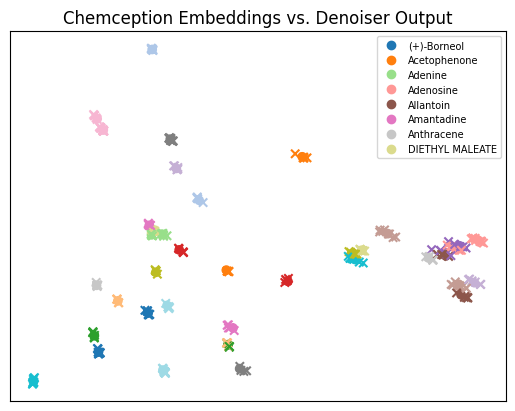

In [ ]:
output_embeddings = [emb.detach().numpy() for emb in predicted_embeddings]
plot_emb_pca(embeddings, sorted_chem_names, output_embeddings, output_chem_names)

In [ ]:
# torch.save(encoder.state_dict(), encoder_path)

# Train Generator:
---

In [ ]:
epochs = 300
learning_rate = .001

encoder = Encoder()
encoder.load_state_dict(torch.load(encoder_path))

generator = Generator()
generator_optimizer = torch.optim.AdamW(generator.parameters(), lr = learning_rate)
generator_criterion = nn.MSELoss()

predicted_spectra = []
original_spectra = []
output_chem_names = []

for epoch in range(epochs):
  epoch_training_loss = 0

  for batch, name_encodings, true_embeddings in train_dataset:
    batch_predicted_embeddings = encoder(batch)
    batch_predicted_spectra = generator(batch_predicted_embeddings.detach())

    loss = generator_criterion(batch_predicted_spectra, batch)
    epoch_training_loss += loss

    # back propogation
    generator_optimizer.zero_grad()
    loss.backward()
    generator_optimizer.step()

    # at last epoch store output spectra, true spectra and corresponding labels to output list
    if epoch+1 == epochs:
      chem_names = [sorted_chem_names[list(encoding).index(1)] for encoding in name_encodings]
      for pred_spec, true_spec, chem_name in zip(batch_predicted_spectra, batch, chem_names):
        predicted_spectra.append(pred_spec)
        original_spectra.append(true_spec)
        output_chem_names.append(chem_name)

  average_loss = epoch_training_loss/len(train_dataset)


  if (epoch + 1) % 10 == 0:
    print('Epoch[{}/{}], Generator loss: {:.4f}'.format(epoch+1, epochs, average_loss))

Epoch[10/300], Generator loss: 21.9525
Epoch[20/300], Generator loss: 21.2486
Epoch[30/300], Generator loss: 20.6985
Epoch[40/300], Generator loss: 20.0245
Epoch[50/300], Generator loss: 18.4001
Epoch[60/300], Generator loss: 17.9393
Epoch[70/300], Generator loss: 17.1738
Epoch[80/300], Generator loss: 17.4460
Epoch[90/300], Generator loss: 16.6109
Epoch[100/300], Generator loss: 16.0324
Epoch[110/300], Generator loss: 14.6661
Epoch[120/300], Generator loss: 13.4228
Epoch[130/300], Generator loss: 12.9049
Epoch[140/300], Generator loss: 12.2714
Epoch[150/300], Generator loss: 12.2409
Epoch[160/300], Generator loss: 11.9205
Epoch[170/300], Generator loss: 11.7253
Epoch[180/300], Generator loss: 11.8062
Epoch[190/300], Generator loss: 11.5352
Epoch[200/300], Generator loss: 11.6538
Epoch[210/300], Generator loss: 11.2448
Epoch[220/300], Generator loss: 10.7500
Epoch[230/300], Generator loss: 11.1372
Epoch[240/300], Generator loss: 10.2575
Epoch[250/300], Generator loss: 10.0551
Epoch[260

In [ ]:
# torch.save(generator.state_dict(), generator_path)

# Train Encoder on Noisy Spectra:
---

In [ ]:
noisy_dataset = generate_noisy_dataset(x_train, train_chem_encodings, train_embeddings, 32, random_range=random_range)

In [ ]:
epochs = 100
encoder = Encoder()
encoder.load_state_dict(torch.load(encoder_path))

learning_rate = .0001

encoder_optimizer = torch.optim.AdamW(encoder.parameters(), lr = learning_rate)
encoder_criterion = nn.MSELoss()

predicted_embeddings = []
output_chem_names = []

for epoch in range(epochs):
  # accumulate epoch loss
  epoch_training_loss = 0

  for noisy_batch, true_batch, name_encodings, true_embeddings in noisy_dataset:
    batch_predicted_embeddings = encoder(noisy_batch)

    loss = encoder_criterion(batch_predicted_embeddings, true_embeddings)
    epoch_training_loss += loss

    # back propogation
    encoder_optimizer.zero_grad()
    loss.backward()
    encoder_optimizer.step()

    # at last epoch store output embeddings and corresponding labels to output list
    if (epoch + 1) == epochs:
      chem_names = [sorted_chem_names[list(encoding).index(1)] for encoding in name_encodings]
      for emb, chem_name in zip(batch_predicted_embeddings, chem_names):
        predicted_embeddings.append(emb)
        output_chem_names.append(chem_name)

  average_loss = epoch_training_loss/len(noisy_dataset)

  if (epoch + 1) % 10 == 0:
    print('Epoch[{}/{}], loss: {}'.format(epoch+1, epochs, average_loss))

Epoch[10/100], loss: 0.0015150250401347876
Epoch[20/100], loss: 0.000530468299984932
Epoch[30/100], loss: 0.0002371766313444823
Epoch[40/100], loss: 0.00014063103299122304
Epoch[50/100], loss: 0.00011055961658712476
Epoch[60/100], loss: 0.0002471182669978589
Epoch[70/100], loss: 6.348535680444911e-05
Epoch[80/100], loss: 4.608451126841828e-05
Epoch[90/100], loss: 0.0001072594677680172
Epoch[100/100], loss: 4.5768581912852824e-05


In [ ]:
# output_embeddings = [emb.detach().numpy() for emb in predicted_embeddings]
# plot_emb_pca(embeddings, sorted_chem_names, output_embeddings, output_chem_names)

In [ ]:
# torch.save(encoder.state_dict(), noisy_encoder_path)

# Train Generator on Noisy Data:
---

In [ ]:
noisy_dataset = generate_noisy_dataset(x_train, train_chem_encodings, train_embeddings, 32, random_range=random_range, fill_num=150)

In [ ]:
epochs = 100

encoder = Encoder()
encoder.load_state_dict(torch.load(encoder_path))

generator = Generator()
generator.load_state_dict(torch.load(generator_path))

learning_rate = .001

optimizer = torch.optim.AdamW(generator.parameters(), lr = learning_rate)
criterion = nn.MSELoss()

original_spectra = []
predicted_spectra = []
output_chem_names = []

run_with_wandb(config, truth=truth)

for epoch in range(epochs):
  # noisy_dataset = generate_noisy_dataset(x_train, train_chem_encodings, train_embeddings, 100, random_range=random_range, num_noisy_per_real=1)
  # accumulate epoch loss
  epoch_training_loss = 0

  for noisy_batch, true_batch, name_encodings, true_embeddings in noisy_dataset:
    batch_predicted_embeddings = encoder(noisy_batch)
    batch_predicted_spectra = generator(batch_predicted_embeddings.detach())

    loss = criterion(batch_predicted_spectra, true_batch)
    epoch_training_loss += loss

    # back propogation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # at last epoch store output spectra, true spectra and corresponding labels to output list
    if epoch+1 == epochs:
      chem_names = [sorted_chem_names[list(encoding).index(1)] for encoding in name_encodings]
      for pred_spec, true_spec, chem_name in zip(batch_predicted_spectra, true_batch, chem_names):
        predicted_spectra.append(pred_spec)
        original_spectra.append(true_spec)
        output_chem_names.append(chem_name)

  average_loss = epoch_training_loss/len(noisy_dataset)
  wandb.log({"Spider Training Loss": average_loss})

  if (epoch + 1) % 10 == 0:
    print('Epoch[{}/{}], Generator loss: {:.4f}'.format(epoch+1, epochs, average_loss))

wandb.finish()

wandb: Currently logged in as: catemerfeld. Use `wandb login --relogin` to force relogin


Using device: cpu


Spider Training Loss,▁
Spider Training Loss,13.6844


In [ ]:
torch.save(generator.state_dict(), noisy_generator_path)

In [ ]:
# plotting_true_spectra = [spec.detach().numpy() for spec in original_spectra]
# plotting_output_spectra = [spec.detach().numpy() for spec in predicted_spectra]

# plot_results(plotting_true_spectra, plotting_output_spectra, output_chem_names)

In [ ]:
# # UNCLEAR if we even care about test performance? If the objective is just to identify unseen samples with the classifier then it doesn't matter how well they do here...
# generator.eval()
# test_output = []
# test_true_spectra = []
# test_output_labels = []
# test_loss = 0

# with torch.no_grad():
#   for noisy_batch, true_batch, name_encodings, true_embeddings in noisy_test_dataset:
#     batch_predicted_embeddings = encoder(noisy_batch)
#     batch_predicted_spectra = generator(batch_predicted_embeddings.detach())

#     loss = generator_criterion(batch_predicted_spectra, true_batch)
#     test_loss+=loss

#     chem_names = [sorted_chem_names[list(encoding).index(1)] for encoding in name_encodings]
#     for pred_spec, true_spec, chem_name in zip(batch_predicted_spectra, true_batch, chem_names):
#       test_output.append(pred_spec)
#       test_true_spectra.append(true_spec)
#       test_output_labels.append(chem_name)

#   average_loss = test_loss/len(noisy_test_dataset)
#   print('Loss =', average_loss)

# Train Individual Generators:
---

In [ ]:
frequency_dict = defaultdict(int)
for item in train_chems:
    frequency_dict[item] += 1

train_df_cols = []
for item in train_chems:
    suffix = frequency_dict[item]
    new_item = f"{item}.{suffix}"
    train_df_cols.append(new_item)
    frequency_dict[item] -= 1

train_df = pd.DataFrame(x_train.T, columns=train_df_cols)

In [ ]:
chem_columns = list(train_df.filter(like='Fluorene').columns)
chem_subset = train_df[chem_columns].T
noisy_single_chem_dataset = generate_noisy_dataset(x_train, train_chem_encodings, train_embeddings, 100, random_range=random_range)

In [ ]:
epochs = 50

encoder = Encoder()
encoder.load_state_dict(torch.load(noisy_encoder_path))

generator = Generator()
generator.load_state_dict(torch.load(noisy_generator_path))

optimizer = torch.optim.AdamW(generator.parameters(), lr = learning_rate)
criterion = nn.MSELoss()
learning_rate = .001

original_spectra = []
predicted_spectra = []
output_chem_names = []

run_with_wandb(config, truth=truth)

for epoch in range(epochs):
  # accumulate epoch loss
  epoch_training_loss = 0

  for noisy_batch, true_batch, name_encodings, true_embeddings in noisy_single_chem_dataset:
    batch_predicted_embeddings = encoder(noisy_batch)
    batch_predicted_spectra = generator(batch_predicted_embeddings.detach())

    loss = criterion(batch_predicted_spectra, true_batch)
    epoch_training_loss += loss

    # back propogation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # at last epoch store output spectra, true spectra and corresponding labels to output list
    if epoch+1 == epochs:
      chem_names = [sorted_chem_names[list(encoding).index(1)] for encoding in name_encodings]
      for pred_spec, true_spec, chem_name in zip(batch_predicted_spectra, true_batch, chem_names):
        predicted_spectra.append(pred_spec)
        original_spectra.append(true_spec)
        output_chem_names.append(chem_name)

  average_loss = epoch_training_loss/len(noisy_dataset)
  wandb.log({"Individual Chem Generator Training Loss": average_loss})

  if (epoch + 1) % 10 == 0:
    print('Epoch[{}/{}], Generator loss: {:.4f}'.format(epoch+1, epochs, average_loss))

wandb.finish()

Using device: cpu
Epoch[10/50], Generator loss: 3.5107
Epoch[20/50], Generator loss: 3.6036
Epoch[30/50], Generator loss: 3.5650
Epoch[40/50], Generator loss: 3.6155
Epoch[50/50], Generator loss: 3.5725


Individual Chem Generator Training Loss,▆▆▄▅▃▅▆▂▁▂▁▂▅▇▄▂▂▄▃▆▄▅▃▆▅▄█▅▄▅▆▁▃▃▄▄▁▅▃▅
Individual Chem Generator Training Loss,3.57246


# Evaluate Synthetic Data:

In [ ]:
frequency_dict = defaultdict(int)
for item in train_chems:
    frequency_dict[item] += 1

train_df_cols = []
for item in train_chems:
    suffix = frequency_dict[item]
    new_item = f"{item}.{suffix}"
    train_df_cols.append(new_item)
    frequency_dict[item] -= 1

train_df = pd.DataFrame(x_train.T, columns=train_df_cols)

In [ ]:
average_sims = {}
# Calculate pairwise similarity between all spectra for each chemical
for chem in sorted_chem_names:
    chem_similarities = []

    if not chem == '(5R,11R)-5,11-Dimethylpentacosane':
      chem_columns = list(train_df.filter(like=chem).columns)
      chem_subset = train_df[chem_columns].T.values
      for i, j in combinations(range(len(chem_subset)), 2):
        similarity = get_weighted_cosine_similarity(chem_subset[i], chem_subset[j])
        chem_similarities.append(similarity.item())

      average_sims[chem] = np.mean(chem_similarities)

In [ ]:
# Use generator to create synthetic spectra
generator = Generator()
generator.load_state_dict(torch.load(noisy_generator_path))
generator.eval()

encoder = Encoder()
encoder.load_state_dict(torch.load(noisy_encoder_path))
encoder.eval()

eval_output = []
eval_true_spectra = []
eval_output_labels = []

with torch.no_grad():
  for noisy_batch, true_batch, name_encodings, true_embeddings in noisy_dataset:
    batch_predicted_embeddings = encoder(noisy_batch)
    batch_predicted_spectra = generator(batch_predicted_embeddings.detach())

    chem_names = [sorted_chem_names[list(encoding).index(1)] for encoding in name_encodings]
    for pred_spec, true_spec, chem_name in zip(batch_predicted_spectra, true_batch, chem_names):
      if not chem_name == '(5R,11R)-5,11-Dimethylpentacosane':
        eval_output.append(pred_spec)
        eval_true_spectra.append(true_spec)
        eval_output_labels.append(chem_name)

In [ ]:
synthetic_sims = []
dissimilar_synthetic = []
dissimilar_true = []
for synthetic_spec, true_spec, chem in zip(eval_output, eval_true_spectra, eval_output_labels):
    # divide difference between synthetic and true spectra (for chem X) by average difference between true spectra for chem X
    sim = get_weighted_cosine_similarity(synthetic_spec, true_spec)
    if sim < .2:
      dissimilar_synthetic.append(synthetic_spec.detach().numpy())
      dissimilar_true.append(true_spec.detach().numpy())
    sim_ratio = sim/average_sims[chem]
    synthetic_sims.append(sim_ratio.detach().numpy())

In [ ]:
# plot_results(dissimilar_true, dissimilar_synthetic, output_chem_names)

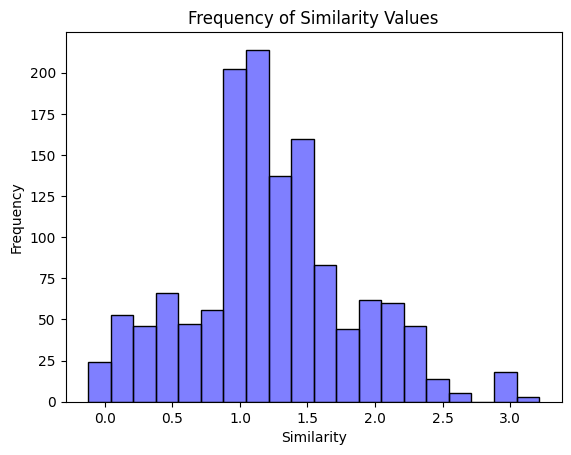

In [ ]:
flattened_sims = np.concatenate([arr.flatten() for arr in synthetic_sims])
sns.histplot(flattened_sims, bins=20, kde=False, color='blue', alpha=0.5)

# Set the labels and title
plt.xlabel('Similarity')
plt.ylabel('Frequency')
plt.title('Frequency of Similarity Values')

plt.show()

In [ ]:
num_above_pt_89 = 0
for sim in flattened_sims:
  if sim >= .9:
    num_above_pt_89 += 1
print(num_above_pt_89/len(flattened_sims))

0.7731343283582089


In [ ]:
avg_cosine_sim = 0
avg_mse = 0

mse = nn.MSELoss()

for true_spec, synthetic_spec in zip(eval_true_spectra, eval_output):
  cos_sim = get_weighted_cosine_similarity(synthetic_spec, true_spec)
  avg_cosine_sim += cos_sim
  avg_mse += mse(synthetic_spec, true_spec)

avg_cosine_sim /= len(eval_output)
avg_mse /= len(eval_output)

print(avg_cosine_sim)
print(avg_mse)

tensor(0.7087)
tensor(12.0627)


In [ ]:
# plotting_true_spectra = [spec.detach().numpy() for spec in test_true_spectra]
# plotting_output_spectra = [spec.detach().numpy() for spec in test_output]

# plot_results(plotting_true_spectra, plotting_output_spectra, test_output_labels)

In [ ]:
# save_specs = [[float(num.item()) for num in spec] for spec in [spec.detach() for spec in predicted_spectra]]

# df = pd.DataFrame(save_specs).T
# df.columns = output_chem_names

# df.to_csv('/content/drive/MyDrive/grad_school/thesis/mass_spec/data/artificial_spectra_5_per_real_150_blank.csv', index=False)

# Evaluate Synthetic Test Data:
---

In [ ]:
frequency_dict = defaultdict(int)
for item in test_chems:
    frequency_dict[item] += 1

test_df_cols = []
for item in test_chems:
    suffix = frequency_dict[item]
    new_item = f"{item}.{suffix}"
    test_df_cols.append(new_item)
    frequency_dict[item] -= 1

test_df = pd.DataFrame(x_test.T, columns=test_df_cols)

In [ ]:
average_sims = {}
# Calculate pairwise similarity between all spectra for each chemical
for chem in sorted_chem_names:
    chem_similarities = []

    if not chem == '(5R,11R)-5,11-Dimethylpentacosane':
      chem_columns = list(spectra_df.filter(like=chem).columns)
      chem_subset = spectra_df[chem_columns].T.values
      for i, j in combinations(range(len(chem_subset)), 2):
        similarity = get_weighted_cosine_similarity(chem_subset[i], chem_subset[j])
        chem_similarities.append(similarity.item())

      average_sims[chem] = np.mean(chem_similarities)

In [ ]:
test_noisy_dataset = generate_noisy_dataset(x_test, test_chem_encodings, test_embeddings, 32, random_range=random_range, fill_num=150, num_noisy_per_real=1)

In [ ]:
# Use generator to create synthetic spectra
generator = Generator()
generator.load_state_dict(torch.load(noisy_generator_path))
generator.eval()

encoder = Encoder()
encoder.load_state_dict(torch.load(noisy_encoder_path))
encoder.eval()

test_output = []
test_true_spectra = []
test_output_labels = []

with torch.no_grad():
  for noisy_batch, true_batch, name_encodings, true_embeddings in test_noisy_dataset:
    batch_predicted_embeddings = encoder(noisy_batch)
    batch_predicted_spectra = generator(batch_predicted_embeddings.detach())

    chem_names = [sorted_chem_names[list(encoding).index(1)] for encoding in name_encodings]
    for pred_spec, true_spec, chem_name in zip(batch_predicted_spectra, true_batch, chem_names):
      if not chem_name == '(5R,11R)-5,11-Dimethylpentacosane':
        test_output.append(pred_spec)
        test_true_spectra.append(true_spec)
        test_output_labels.append(chem_name)

In [ ]:
synthetic_sims = []
dissimilar_synthetic = []
dissimilar_true = []
for synthetic_spec, true_spec, chem in zip(test_output, test_true_spectra, test_output_labels):
    # divide difference between synthetic and true spectra (for chem X) by average difference between true spectra for chem X
    sim = get_weighted_cosine_similarity(synthetic_spec, true_spec)
    if sim < .2:
      dissimilar_synthetic.append(synthetic_spec.detach().numpy())
      dissimilar_true.append(true_spec.detach().numpy())
    sim_ratio = sim/average_sims[chem]
    synthetic_sims.append(sim_ratio.detach().numpy())

In [ ]:
# plot_results(dissimilar_true, dissimilar_synthetic, output_chem_names)

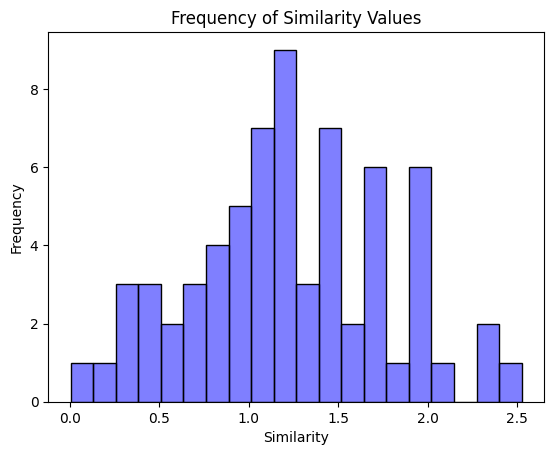

In [ ]:
flattened_sims = np.concatenate([arr.flatten() for arr in synthetic_sims])
sns.histplot(flattened_sims, bins=20, kde=False, color='blue', alpha=0.5)

# Set the labels and title
plt.xlabel('Similarity')
plt.ylabel('Frequency')
plt.title('Frequency of Similarity Values')

plt.show()

In [ ]:
num_above_pt_89 = 0
for sim in flattened_sims:
  if sim >= .9:
    num_above_pt_89 += 1
print(num_above_pt_89/len(flattened_sims))

0.7761194029850746


In [ ]:
avg_cosine_sim = 0
avg_mse = 0

mse = nn.MSELoss()

for true_spec, synthetic_spec in zip(eval_true_spectra, eval_output):
  cos_sim = get_weighted_cosine_similarity(synthetic_spec, true_spec)
  avg_cosine_sim += cos_sim
  avg_mse += mse(synthetic_spec, true_spec)

avg_cosine_sim /= len(eval_output)
avg_mse /= len(eval_output)

print(avg_cosine_sim)
print(avg_mse)

tensor(0.7087)
tensor(12.0627)


# Train Random Forest:
---

In [ ]:
# Use generator to create synthetic spectra
generator = Generator()
generator.load_state_dict(torch.load(noisy_generator_path))
generator.eval()

encoder = Encoder()
encoder.load_state_dict(torch.load(noisy_encoder_path))
encoder.eval()

predicted_spectra = []
output_chem_names = []

with torch.no_grad():
  for noisy_batch, true_batch, name_encodings, true_embeddings in noisy_dataset:
    batch_predicted_embeddings = encoder(noisy_batch)
    batch_predicted_spectra = generator(batch_predicted_embeddings.detach())

    chem_names = [sorted_chem_names[list(encoding).index(1)] for encoding in name_encodings]
    for pred_spec, true_spec, chem_name in zip(batch_predicted_spectra, true_batch, chem_names):
      predicted_spectra.append(pred_spec)
      output_chem_names.append(chem_name)

In [ ]:
train_labels = [sorted_chem_names[list(encoding).index(1)] for encoding in train_chem_encodings]
test_labels = [sorted_chem_names[list(encoding).index(1)] for encoding in test_chem_encodings]

# create random forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100)

# train and generate preds on only real spectra
rf_classifier.fit(x_train, train_labels)
preds = rf_classifier.predict(x_test)

# evaluate prediction accuracy
real_accuracy = accuracy_score(test_labels, preds)
print(f'Accuracy Score for real data: {round((100*real_accuracy))}%')

Accuracy Score for real data: 73%


In [ ]:
spectra_preds_tensor = torch.stack(predicted_spectra)
augmented_dataset = torch.cat((spectra_preds_tensor.clone().detach(), x_train))
augmented_dataset_labels = output_chem_names + train_labels

# create random forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100)

# train and generate preds on augmented dataset
rf_classifier.fit(augmented_dataset, augmented_dataset_labels)
preds = rf_classifier.predict(x_test)

# evaluate prediction accuracy
real_accuracy = accuracy_score(test_labels, preds)
print(f'Accuracy Score for real and synthetic data: {round((100*real_accuracy))}%')

Accuracy Score for real and synthetic data: 79%
